# SRILM: 2-Gram & 3-Gram

## Setup

In [1]:
import kenlm  # to load SRILM binary files
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import sys
import os

In [2]:
os.environ['PATH'] = "/home/lawun330/NLP/SRILM/bin/i686-m64:" + os.environ['PATH']
!echo $PATH

/home/lawun330/NLP/SRILM/bin/i686-m64:/home/lawun330/anaconda3/envs/lu_burmese_domain_specific_lm_env/bin:/home/lawun330/.local/bin:/home/lawun330/.config/herd-lite/bin:/home/lawun330/.cargo/bin:/home/lawun330/.local/bin:/home/lawun330/.nvm/versions/node/v22.22.2/bin:/home/lawun330/anaconda3/condabin:/home/lawun330/.local/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/usr/games:/usr/local/games:/snap/bin:/snap/bin


In [3]:
!ngram-count -help

Usage of command "ngram-count"
 -version:                 print version information
 -order:                   max ngram order
		Default value: 3
 -varprune:                pruning threshold for variable order ngrams
		Default value: 0
 -debug:                   debugging level for LM
		Default value: 0
 -recompute:               recompute lower-order counts by summation
 -sort:                    sort ngrams output
 -write-order:             output ngram counts order
		Default value: 0
 -tag:                     file tag to use in messages
 -text:                    text file to read
 -text-has-weights:        text file contains count weights
 -text-has-weights-last:   text file contains count weights at ends of lines
 -no-sos:                  don't insert start-of-sentence tokens
 -no-eos:                  don't insert end-of-sentence tokens
 -read:                    counts file to read
 -intersect:               intersect counts with this file
 -read-with-mincounts:     apply mini

In [4]:
ROOT = Path("..").resolve()

TRAIN_DATA = ROOT / "data" / "train" / "combined_2.cleaned.state3"
SRILM_DIR = ROOT / "models" / "srilm"
TMP_DIR = f"{SRILM_DIR}/tmp"

TEST_NEWS_DOMAIN = ROOT / "data" / "test" / "news.cleaned.state4"
TEST_LEGAL_DOMAIN = ROOT / "data" / "test" / "legal.cleaned.state4"
TEST_RELIGION_DOMAIN = ROOT / "data" / "test" / "religion.cleaned.state4"

CORPORA = [
    ("train", TRAIN_DATA),
    ("news", TEST_NEWS_DOMAIN),
    ("legal", TEST_LEGAL_DOMAIN),
    ("religion", TEST_RELIGION_DOMAIN),
]

EVAL_SCRIPT = ROOT / "eval_kenlm_srilm.py"

sys.path.insert(0, str(ROOT))
import eval_kenlm_srilm

## Load Dataset

In [5]:
train_data = f"{TRAIN_DATA}"
df = pd.read_csv(train_data, header=None, names=["text"])
print(df.shape)
df.head()

(63302, 1)


,text
0,ပြင် သစ် နိုင် ငံ ပါ ရီ မြို့ ပါ့ ဒက်စ် ပ ရ င့...
1,အန် ဒ ရီ ယာ မာ စီ သည် အီ တ လီ အ တွက် စမ်း သပ် ...
2,ပ ထ မ တစ် ဝက် ၏ တော် တော် များ များ အ တွက် က စ...
3,ပေါ် တူ ဂီ သည် ဘယ် သော အ ခါ မှ စွ န့် လွှတ် မှ...
4,အီ တ လီ သည် ပ ထ မ ပိုင်း ၌ ၁၆ ၅ ဖြ င့် ဦး ဆောင...


## SRILM Setup: 2-Gram Model (No Interpolation)

### Constants

In [6]:
arpa_file_2_gram = f"{SRILM_DIR}/srilm_2gram.arpa"

### Smoothing

Smoothing prevents zero probability assignments by redistributing probability mass. In backoff-based models, enabling fallback to lower-order n-grams when higher-order n-grams are unseen.

### Discounting

Discounting is a technique used inside many smoothing methods.

### Model Training

- `-order 2` specifies a 2-gram language model.
- `-kndiscount` turns on Kneser–Ney discounting.
- `-wbdiscount` turns on Witten-Bell discounting (alternative smoothing for sparse train data)
- `-text {TRAIN_DATA}` is the training text file (one line per sentence for this corpus).
- `-lm {arpa_file_2_gram}` is the output language model path.
- `-unk` treats OOV words as a special token during count estimation.
- `-map-unk "<unk>"` maps OOV surface forms to the symbol `<unk>` so they share one vocabulary entry (aligns with ARPA `<unk>` handling).

The command then:

- saves the trained language model to the specified ARPA file,
- and redirects error messages (stderr) to a separate log file for debugging.

In [7]:
# run with Kneser-Ney discounting
!ngram-count \
    -order 2 \
    -text {TRAIN_DATA} \
    -lm {arpa_file_2_gram} \
    -kndiscount \
    -unk \
    -map-unk "<unk>" \
    2>{arpa_file_2_gram}.error

In [8]:
# run with Witten-Bell discounting if above fails due to small train data
# !ngram-count \
#     -order 2 \
#     -text {TRAIN_DATA} \
#     -lm {arpa_file_2_gram} \
#     -wbdiscount \
#     -unk \
#     -map-unk "<unk>" \
#     2>{arpa_file_2_gram}.error

### ARPA to Binary

This file conversion allows the model to load faster.

There are two ways to convert an SRILM ARPA file to binary format.
1. Use the native SRILM `ngram` command.
2. Use the `build_binary` command from KenLM.

In [9]:
!ngram -order 2 -lm {arpa_file_2_gram} -write-bin-lm {arpa_file_2_gram}.bin

/home/lawun330/Desktop/burmese-domain-specific-lm/models/srilm/srilm_2gram.arpa: line 86: warning: non-zero probability for <unk> in closed-vocabulary LM


### Loading the Model

In [10]:
try:
    model_srilm_2g = kenlm.LanguageModel(f"{arpa_file_2_gram}.bin")
except:
    print("Error: The binary file generated by the native SRILM ngram command cannot be read by kenlm.LanguageModel().")
    print("The KenLM build_binary command should be used to rebuild the binary file from the SRILM ARPA file.")
    print()

Error: The binary file generated by the native SRILM ngram command cannot be read by kenlm.LanguageModel().
The KenLM build_binary command should be used to rebuild the binary file from the SRILM ARPA file.



Loading the LM will be faster if you build a binary file.
Reading /home/lawun330/Desktop/burmese-domain-specific-lm/models/srilm/srilm_2gram.arpa.bin
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************


In [11]:
# rebuild binary file using KenLM command
!build_binary {arpa_file_2_gram} {arpa_file_2_gram}.ken.binary

Reading /home/lawun330/Desktop/burmese-domain-specific-lm/models/srilm/srilm_2gram.arpa
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
SUCCESS


In [12]:
try:
    model_srilm_2g = kenlm.LanguageModel(f"{arpa_file_2_gram}.ken.binary")
except:
    print("Error: The binary file generated by the KenLM build_binary command cannot be read by kenlm.LanguageModel().")
    print()

### Exploring the Model

In [13]:
!tail -30 {arpa_file_2_gram}

-1.294248	…… ပိတ်
-1.294248	…… ပြည်
-1.294248	…… ရှာ
-1.294248	…… အ
-1.294248	…… ၎င်း
-0.4491503	€ ၄၂
-0.9262716	− မန္တ
-0.9262716	− မြန်
-0.9262716	− ၂၀၁၃
-0.4491503	、 集體創新
-0.4491503	おじいさん အ
-0.4491503	おじさん ဦး
-0.4491503	つ ဆို
-0.4491503	つなみ ဟူ
-0.4491503	ビルマ人 ဟု
-0.4491503	ミャンマー ဟု
-0.4491503	・ 008
-0.4491503	匯聚 智
-0.4491503	慧 、
-0.4491503	新加坡 pinyin
-0.7501802	日本語 သည်
-0.7501802	日本語 ဟု
-0.4491503	昭南島 Shōnantō
-0.4491503	昭和の時代に得た南の島 သို့
-0.4491503	智 慧
-0.4491503	缅甸 သုံး
-0.4491503	集體創新 RRB
-0.4491503	﻿ တင်

\end\


In [14]:
!cat {arpa_file_2_gram}.error

### Model Evaluation

In [15]:
# on train data
!ngram -lm {arpa_file_2_gram}.bin -ppl {TRAIN_DATA}

file /home/lawun330/Desktop/burmese-domain-specific-lm/data/train/combined_2.cleaned.state3: 63302 sentences, 1878654 words, 0 OOVs
0 zeroprobs, logprob= -3346389 ppl= 52.86951 ppl1= 60.43233


In [16]:
!ngram -lm {arpa_file_2_gram}.bin -ppl {TEST_NEWS_DOMAIN}

file /home/lawun330/Desktop/burmese-domain-specific-lm/data/test/news.cleaned.state4: 15 sentences, 300 words, 0 OOVs
0 zeroprobs, logprob= -685.0879 ppl= 149.583 ppl1= 192.1438


In [17]:
!ngram -lm {arpa_file_2_gram}.bin -ppl {TEST_LEGAL_DOMAIN}

file /home/lawun330/Desktop/burmese-domain-specific-lm/data/test/legal.cleaned.state4: 15 sentences, 300 words, 0 OOVs
0 zeroprobs, logprob= -742.2229 ppl= 227.1241 ppl1= 297.904


In [18]:
!ngram -lm {arpa_file_2_gram}.bin -ppl {TEST_RELIGION_DOMAIN}

file /home/lawun330/Desktop/burmese-domain-specific-lm/data/test/religion.cleaned.state4: 15 sentences, 300 words, 0 OOVs
0 zeroprobs, logprob= -785.093 ppl= 310.7125 ppl1= 413.9774


## SRILM Setup: 3-Gram Model (No Interpolation)

### Constants

In [19]:
arpa_file_3_gram = f"{SRILM_DIR}/srilm_3gram.arpa"

### Model Training

In [20]:
# run with Kneser-Ney discounting
!ngram-count \
    -order 3 \
    -text {TRAIN_DATA} \
    -lm {arpa_file_3_gram} \
    -kndiscount \
    -unk \
    -map-unk "<unk>" \
    2>{arpa_file_3_gram}.error

### ARPA to Binary

In [21]:
# do not use ngram command to generate binary file
!build_binary {arpa_file_3_gram} {arpa_file_3_gram}.ken.binary

Reading /home/lawun330/Desktop/burmese-domain-specific-lm/models/srilm/srilm_3gram.arpa
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
SUCCESS


### Loading the Model

In [22]:
try:
    model_srilm_3g = kenlm.LanguageModel(f"{arpa_file_3_gram}.ken.binary")
except:
    print("Error: The binary file generated by the KenLM build_binary command cannot be read by kenlm.LanguageModel().")
    print()

### Exploring the Model

In [23]:
!tail -30 {arpa_file_3_gram}

-2.789021	၎င်း ၏ လမ်း
-2.789021	၎င်း ၏ လိုင်
-1.92477	၎င်း ၏ လုပ်
-2.545198	၎င်း ၏ လုံ
-2.545198	၎င်း ၏ လူ
-2.331797	၎င်း ၏ လေ
-2.789021	၎င်း ၏ လေ့
-2.545198	၎င်း ၏ လွတ်
-2.789021	၎င်း ၏ လှုပ်
-2.331797	၎င်း ၏ ဝက်
-1.996411	၎င်း ၏ ဝက်ဘ်
-2.545198	၎င်း ၏ ဝန်
-2.082249	၎င်း ၏ သ
-2.545198	၎င်း ၏ သက်
-2.331797	၎င်း ၏ သင်္ဘော
-2.789021	၎င်း ၏ သု
-0.7954096	၎င်း ၏ အ
-2.789021	၎င်း ၏ အက်
-2.789021	၎င်း ၏ အင်္ဂ
-2.331797	၎င်း ၏ အာ
-2.189341	၎င်း ၏ အိမ်
-2.789021	၎င်း ၏ အောက်
-2.789021	၎င်း ၏ ဥ
-2.331797	၎င်း ၏ ဦး
-2.789021	၎င်း ၏ ၁၃
-0.3473258	ကို … ကျွန်ုပ်
-0.4856521	သည် … </s>
-0.9486012	သည် … အ

\end\


In [24]:
!cat {arpa_file_3_gram}.error

### Model Evaluation

In [25]:
# on train data
!ngram -lm {arpa_file_3_gram}.bin -ppl {TRAIN_DATA}

/home/lawun330/Desktop/burmese-domain-specific-lm/models/srilm/srilm_3gram.arpa.bin: No such file or directory


In [26]:
!ngram -lm {arpa_file_3_gram}.bin -ppl {TEST_NEWS_DOMAIN}

/home/lawun330/Desktop/burmese-domain-specific-lm/models/srilm/srilm_3gram.arpa.bin: No such file or directory


In [27]:
!ngram -lm {arpa_file_3_gram}.bin -ppl {TEST_LEGAL_DOMAIN}

/home/lawun330/Desktop/burmese-domain-specific-lm/models/srilm/srilm_3gram.arpa.bin: No such file or directory


In [28]:
!ngram -lm {arpa_file_3_gram}.bin -ppl {TEST_RELIGION_DOMAIN}

/home/lawun330/Desktop/burmese-domain-specific-lm/models/srilm/srilm_3gram.arpa.bin: No such file or directory


## SRILM Setup: 2-Gram Model (Interpolation Inside Model)

Interpolation can be done wih

In [29]:
arpa_file_2_gram_inter = f"{SRILM_DIR}/srilm_2gram_interpolated.arpa"

In [30]:
# run with Kneser-Ney discounting
!ngram-count \
    -order 2 \
    -text {TRAIN_DATA} \
    -lm {arpa_file_2_gram_inter} \
    -kndiscount \
    -interpolate \
    -unk \
    -map-unk "<unk>" \
    2>{arpa_file_2_gram_inter}.error

In [31]:
!build_binary {arpa_file_2_gram_inter} {arpa_file_2_gram_inter}.ken.binary

Reading /home/lawun330/Desktop/burmese-domain-specific-lm/models/srilm/srilm_2gram_interpolated.arpa
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
SUCCESS


In [32]:
try:
    model_srilm_2g_inter = kenlm.LanguageModel(f"{arpa_file_2_gram_inter}.ken.binary")
except:
    print("Error: The binary file generated by the KenLM build_binary command cannot be read by kenlm.LanguageModel().")
    print()

In [33]:
!tail -30 {arpa_file_2_gram_inter}

-1.289418	…… ပိတ်
-1.284354	…… ပြည်
-1.287073	…… ရှာ
-1.242679	…… အ
-1.290932	…… ၎င်း
-0.4490306	€ ၄၂
-0.9255491	− မန္တ
-0.9233145	− မြန်
-0.9261307	− ၂၀၁၃
-0.4491451	、 集體創新
-0.4413977	おじいさん အ
-0.4473281	おじさん ဦး
-0.4472959	つ ဆို
-0.4484408	つなみ ဟူ
-0.4473402	ビルマ人 ဟု
-0.4473402	ミャンマー ဟု
-0.4491451	・ 008
-0.4491451	匯聚 智
-0.4491451	慧 、
-0.4491451	新加坡 pinyin
-0.7383299	日本語 သည်
-0.7465676	日本語 ဟု
-0.4491451	昭南島 Shōnantō
-0.4466924	昭和の時代に得た南の島 သို့
-0.4491451	智 慧
-0.4476141	缅甸 သုံး
-0.4474771	集體創新 RRB
-0.4479285	﻿ တင်

\end\


In [34]:
!cat {arpa_file_2_gram_inter}.error

## SRILM Setup: 3-Gram Model (Interpolation Inside Model)

In [35]:
arpa_file_3_gram_inter = f"{SRILM_DIR}/srilm_3gram_interpolated.arpa"

In [36]:
# run with Kneser-Ney discounting
!ngram-count \
    -order 3 \
    -text {TRAIN_DATA} \
    -lm {arpa_file_3_gram_inter} \
    -kndiscount \
    -interpolate \
    -unk \
    -map-unk "<unk>" \
    2>{arpa_file_3_gram_inter}.error

In [37]:
!build_binary {arpa_file_3_gram_inter} {arpa_file_3_gram_inter}.ken.binary

Reading /home/lawun330/Desktop/burmese-domain-specific-lm/models/srilm/srilm_3gram_interpolated.arpa
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
SUCCESS


In [38]:
try:
    model_srilm_3g_inter = kenlm.LanguageModel(f"{arpa_file_3_gram_inter}.ken.binary")
except:
    print("Error: The binary file generated by the KenLM build_binary command cannot be read by kenlm.LanguageModel().")
    print()

In [39]:
!tail -30 {arpa_file_3_gram_inter}

-2.530929	၎င်း ၏ လမ်း
-2.739462	၎င်း ၏ လိုင်
-1.825806	၎င်း ၏ လုပ်
-2.452846	၎င်း ၏ လုံ
-2.297154	၎င်း ၏ လူ
-2.199767	၎င်း ၏ လေ
-2.623198	၎င်း ၏ လေ့
-2.365537	၎င်း ၏ လွတ်
-2.640204	၎င်း ၏ လှုပ်
-2.290021	၎င်း ၏ ဝက်
-1.98386	၎င်း ၏ ဝက်ဘ်
-2.277091	၎င်း ၏ ဝန်
-1.887412	၎င်း ၏ သ
-2.353222	၎င်း ၏ သက်
-2.295103	၎င်း ၏ သင်္ဘော
-2.651606	၎င်း ၏ သု
-0.7290726	၎င်း ၏ အ
-2.618439	၎င်း ၏ အက်
-2.692041	၎င်း ၏ အင်္ဂ
-2.201318	၎င်း ၏ အာ
-2.104388	၎င်း ၏ အိမ်
-2.486918	၎င်း ၏ အောက်
-2.521487	၎င်း ၏ ဥ
-2.180316	၎င်း ၏ ဦး
-2.772172	၎င်း ၏ ၁၃
-0.3383181	ကို … ကျွန်ုပ်
-0.4461499	သည် … </s>
-0.7672467	သည် … အ

\end\


In [40]:
!cat {arpa_file_3_gram_inter}.error

## Visualization

In [41]:
MODELS = [
    ("2g", model_srilm_2g),
    ("3g", model_srilm_3g),
    ("2g_inter", model_srilm_2g_inter),
    ("3g_inter", model_srilm_3g_inter),
]

In [42]:
rows = []
for corpus_name, corpus_path in CORPORA:
    row = {"corpus": corpus_name}
    for tag, model in MODELS:
        ppl, ent, bpc = eval_kenlm_srilm.evaluate(model, corpus_path)
        row[f"ppl_{tag}"] = ppl
        row[f"ent_{tag}"] = ent
        row[f"bpc_{tag}"] = bpc
    rows.append(row)

In [43]:
df_eval = pd.DataFrame(rows).set_index("corpus")
df_eval

,ppl_2g,ent_2g,bpc_2g,ppl_3g,ent_3g,bpc_3g,ppl_2g_inter,ent_2g_inter,bpc_2g_inter,ppl_3g_inter,ent_3g_inter,bpc_3g_inter
corpus,,,,,,,,,,,,
train,52.869506,3.967827,1.503332,23.744944,3.167370,1.200054,50.303417,3.918073,1.484481,21.898921,3.086437,1.169391
news,149.583006,5.007851,1.866951,123.024798,4.812386,1.794080,148.518813,5.000712,1.864289,120.953095,4.795403,1.787749
legal,227.124054,5.425496,2.027641,179.244206,5.188749,1.939162,229.689232,5.436727,2.031838,182.392539,5.206161,1.945670
religion,310.712487,5.738868,2.151834,275.025653,5.616864,2.106088,617.649946,6.425922,2.409450,551.260499,6.312207,2.366812


In [44]:
x = np.arange(len(df_eval.index))
w = 0.35
metrics = [
    ("ppl", "Perplexity (PPL)", True),   # log scale
    ("ent", "Entropy (nats)", False),
    ("bpc", "Bits per character (BPC)", False),
]

saved: /home/lawun330/Desktop/burmese-domain-specific-lm/img/srilm_2g_vs_3g_metrics.png


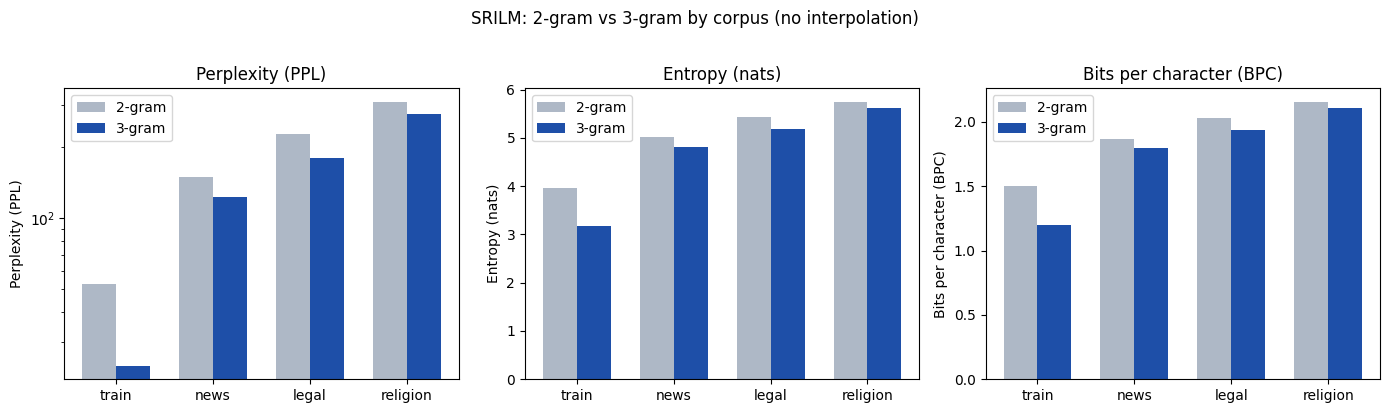

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (prefix, ylabel, use_log) in zip(axes, metrics):
    col_2g = f"{prefix}_2g"
    col_3g = f"{prefix}_3g"
    ax.bar(x - w / 2, df_eval[col_2g], width=w, label="2-gram", color="#AEB8C6")
    ax.bar(x + w / 2, df_eval[col_3g], width=w, label="3-gram", color="#1E4FA8")
    ax.set_xticks(x, df_eval.index)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend()
    if use_log:
        ax.set_yscale("log")

fig.suptitle("SRILM: 2-gram vs 3-gram by corpus (no interpolation)", y=1.02)
plt.tight_layout()

out_path = ROOT / "img" / "srilm_2g_vs_3g_metrics.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print("saved:", out_path)

plt.show()

saved: /home/lawun330/Desktop/burmese-domain-specific-lm/img/srilm_2g_vs_3g_inter_metrics.png


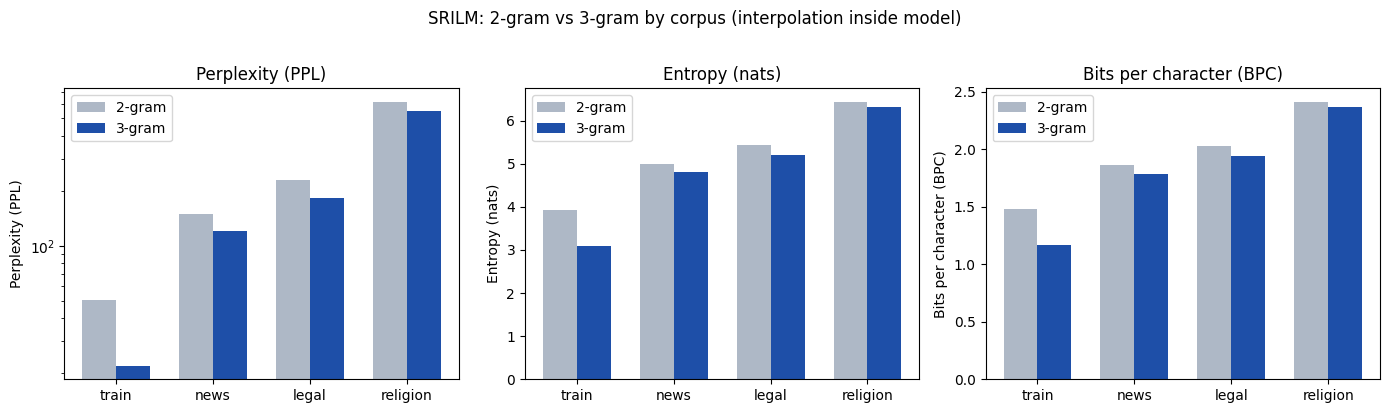

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (prefix, ylabel, use_log) in zip(axes, metrics):
    col_2g = f"{prefix}_2g_inter"
    col_3g = f"{prefix}_3g_inter"
    ax.bar(x - w / 2, df_eval[col_2g], width=w, label="2-gram", color="#AEB8C6")
    ax.bar(x + w / 2, df_eval[col_3g], width=w, label="3-gram", color="#1E4FA8")
    ax.set_xticks(x, df_eval.index)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend()
    if use_log:
        ax.set_yscale("log")

fig.suptitle("SRILM: 2-gram vs 3-gram by corpus (interpolation inside model)", y=1.02)
plt.tight_layout()

out_path = ROOT / "img" / "srilm_2g_vs_3g_inter_metrics.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print("saved:", out_path)

plt.show()

saved: /home/lawun330/Desktop/burmese-domain-specific-lm/img/srilm_3g_plain_vs_inter_metrics.png


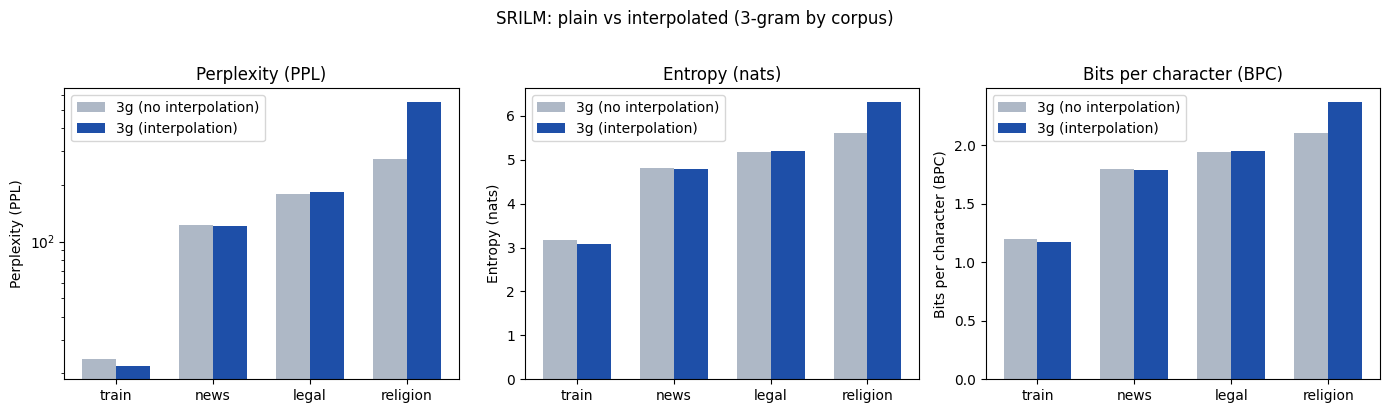

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (prefix, ylabel, use_log) in zip(axes, metrics):
    col_no = f"{prefix}_3g"           # 3-gram, no interpolation
    col_yes = f"{prefix}_3g_inter"    # 3-gram with interpolation (match your df_eval)
    ax.bar(x - w / 2, df_eval[col_no], width=w, label="3g (no interpolation)", color="#AEB8C6")
    ax.bar(x + w / 2, df_eval[col_yes], width=w, label="3g (interpolation)", color="#1E4FA8")
    ax.set_xticks(x, df_eval.index)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend()
    if use_log:
        ax.set_yscale("log")

fig.suptitle("SRILM: plain vs interpolated (3-gram by corpus)", y=1.02)
plt.tight_layout()

out_path = ROOT / "img" / "srilm_3g_plain_vs_inter_metrics.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print("saved:", out_path)

plt.show()

## Conclusion

### Model-Wise
The 3-gram model consistently performs better because it has:

- lower perplexity
- lower entropy
- lower bits-per-character

across every domain with or without interpolation. This shows that adding one more context token clearly improves predictive power.

**Interpolation is not always beneficial** for 3-gram models. It provides a small improvement on the `news` domain, is roughly neutral or slightly worse on the `legal` domain, and significantly degrades performance on the `religion` domain. This suggests that interpolation is a tunable modeling choice rather than a guaranteed improvement.

These facts suggest that:
- local word dependencies matter
- the training mix has useful short-range structure
- 3-gram captures phrase patterns 2-gram misses
- interpolated weights need to match test domain (religion can look much worse under the blended LM)

### Domain-Wise

From easiest to hardest for the model, the domains are:

- news
- legal
- religion

This likely means that:

- news text is closest to the training distribution
- legal text is more formulaic and specialized
- religious text differs the most in vocabulary and writing style